# Project 2: Book Recommender
**Sammi Bronow**

# Book Recommendation System
**Dataset:** GoodReads (Books.csv + Ratings.csv)  
**Part 1** explores the book catalog using Books.csv, which contains full GoodReads aggregate statistics. **Part 2** uses Ratings.csv as the collaborative-filtering interaction matrix.

---
## Part 1: Exploratory Data Analysis

In [1]:
#%pip install scikit-surprise --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from collections import defaultdict
from surprise import KNNBasic, BaselineOnly, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

### 1.1 Load data

In [2]:
books   = pd.read_csv('Books.csv',   encoding='latin-1', on_bad_lines='skip')
ratings = pd.read_csv('Ratings.csv', encoding='latin-1', on_bad_lines='skip')

print(f"Books.csv   : {books.shape[0]:,} rows × {books.shape[1]} columns")
print(f"Ratings.csv : {ratings.shape[0]:,} rows × {ratings.shape[1]} columns")
print()
books.head(3)

Books.csv   : 9,964 rows × 16 columns
Ratings.csv : 164,728 rows × 3 columns



,book_id,isbn,authors,original_publication_year,title,language_code,average_rating,ratings_count,text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,439023483,Suzanne Collins,2008.0,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,439554934,"J.K. Rowling, Mary GrandPrÃÂ©",1997.0,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,316015849,Stephenie Meyer,2005.0,"Twilight (Twilight, #1)",en-US,3.57,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...


### 1.2 Catalog overview

In [3]:
print("Data types:")
print(books.dtypes)
print()
print("Missing values:")
print(books.isnull().sum()[books.isnull().sum() > 0])
print()
print("Key statistics (Books.csv):")
print(books[['average_rating','ratings_count','text_reviews_count',
             'original_publication_year']].describe().round(1))

Data types:
book_id                        int64
isbn                          object
authors                       object
original_publication_year    float64
title                         object
language_code                 object
average_rating               float64
ratings_count                  int64
text_reviews_count             int64
ratings_1                      int64
ratings_2                      int64
ratings_3                      int64
ratings_4                      int64
ratings_5                      int64
image_url                     object
small_image_url               object
dtype: object

Missing values:
isbn                          698
original_publication_year      21
language_code                1076
dtype: int64

Key statistics (Books.csv):
       average_rating  ratings_count  text_reviews_count  \
count          9964.0         9964.0              9964.0   
mean              4.0        59834.2              2927.1   
std               0.3       168087.4     

Books.csv contains full GoodReads aggregate statistics. `ratings_count` and `ratings_1` through `ratings_5` reflect every rating ever submitted for each book, not a sample from Ratings.csv. Missing values are limited to `isbn` (698 books), `language_code` (1,076 books), and `original_publication_year` (21 books), none of which affect the core rating analysis.

### 1.3 Rating volume: how many people rated each book?

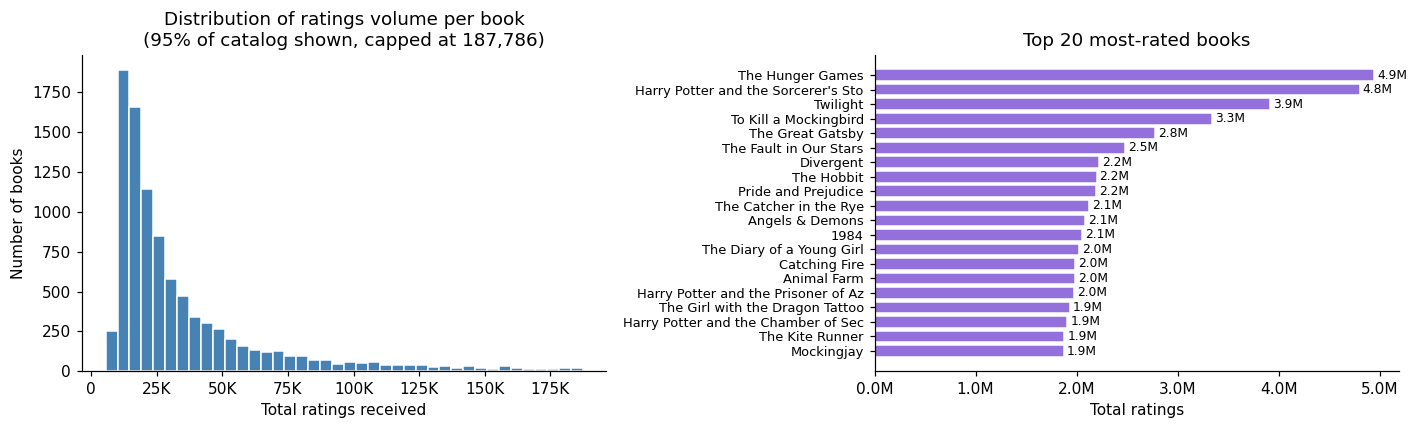

Median ratings per book : 23,908
Mean   ratings per book : 59,834
Books with > 1M ratings : 60
Books with < 10K ratings : 240


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: 95th percentile cap so the bulk of the distribution is visible
cap = int(books['ratings_count'].quantile(0.95))
trimmed = books[books['ratings_count'] <= cap]['ratings_count']
axes[0].hist(trimmed, bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Total ratings received')
axes[0].set_ylabel('Number of books')
axes[0].set_title(f'Distribution of ratings volume per book\n(95% of catalog shown, capped at {cap:,})')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x/1e3)}K' if x >= 1000 else str(int(x))))

# Right: top 20 most-rated books with exact values at end of each bar
top20 = books[['title','ratings_count']].sort_values('ratings_count', ascending=False).head(20)
short_titles = top20['title'].str.extract(r'^([^(:#]+)')[0].str.strip().str[:35]
axes[1].barh(range(20), top20['ratings_count'].values[::-1], color='mediumpurple', edgecolor='white')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(short_titles.values[::-1], fontsize=8.5)
axes[1].set_xlabel('Total ratings')
axes[1].set_title('Top 20 most-rated books')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for i, v in enumerate(top20['ratings_count'].values[::-1]):
    axes[1].text(v + 30_000, i, f'{v/1e6:.1f}M', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f"Median ratings per book : {books['ratings_count'].median():,.0f}")
print(f"Mean   ratings per book : {books['ratings_count'].mean():,.0f}")
print(f"Books with > 1M ratings : {(books['ratings_count'] > 1_000_000).sum()}")
print(f"Books with < 10K ratings : {(books['ratings_count'] < 10_000).sum()}")

Rating volume is extremely right-skewed. Most books in the catalog have received fewer than 200,000 ratings, while a small number of blockbuster titles far exceed that range. The Hunger Games alone has nearly 5 million ratings. This long-tail distribution is typical of recommendation system datasets: popularity compounds as more readers discover and rate the same titles. A pure popularity-based recommender would surface only these mega-titles for every user, which is the motivation for personalized approaches like collaborative filtering.

### 1.4 Average rating distribution: how well-rated is the catalog?

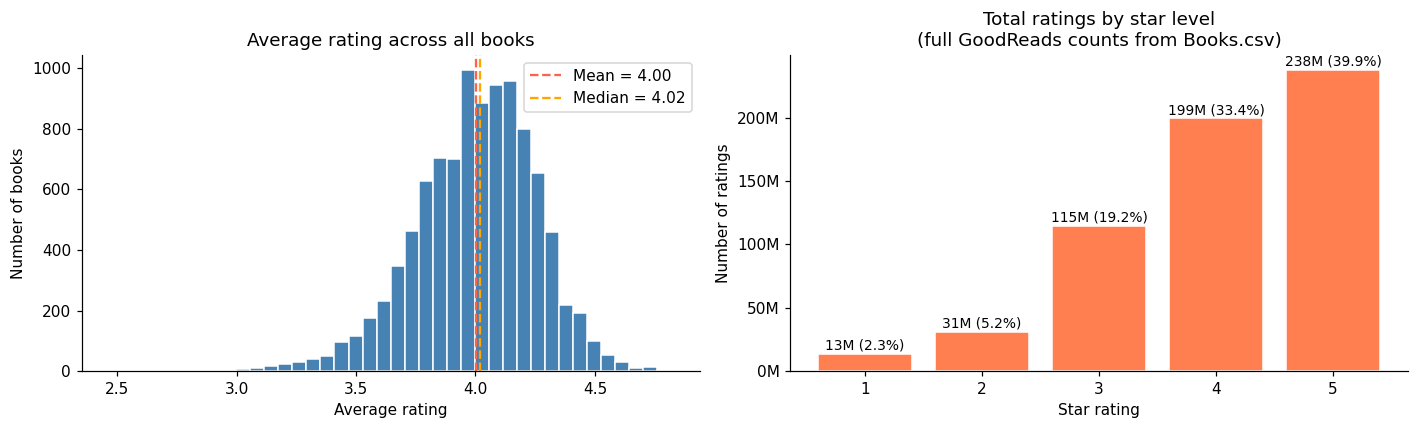

Star-level breakdown (full catalog):
  1 stars:   13,438,597  (2.3%)
  2 stars:   31,073,696  (5.2%)
  3 stars:  114,614,038  (19.2%)
  4 stars:  199,420,975  (33.4%)
  5 stars:  237,640,173  (39.9%)
  Total :  596,187,479


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: distribution of average_rating
axes[0].hist(books['average_rating'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(books['average_rating'].mean(), color='tomato', linestyle='--', linewidth=1.5,
                label=f"Mean = {books['average_rating'].mean():.2f}")
axes[0].axvline(books['average_rating'].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f"Median = {books['average_rating'].median():.2f}")
axes[0].set_xlabel('Average rating')
axes[0].set_ylabel('Number of books')
axes[0].set_title('Average rating across all books')
axes[0].legend()

# Right: full star-level breakdown across entire catalog (Books.csv aggregate)
full_counts = {star: books[f'ratings_{star}'].sum() for star in range(1, 6)}
total = sum(full_counts.values())
axes[1].bar(list(full_counts.keys()), list(full_counts.values()), color='coral', edgecolor='white')
axes[1].set_xlabel('Star rating')
axes[1].set_ylabel('Number of ratings')
axes[1].set_title('Total ratings by star level\n(full GoodReads counts from Books.csv)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e6):.0f}M'))
for star, v in full_counts.items():
    axes[1].text(star, v + 1_000_000, f'{v/1e6:.0f}M ({v/total:.1%})',
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("Star-level breakdown (full catalog):")
for star, v in full_counts.items():
    print(f"  {star} stars: {v:>12,}  ({v/total:.1%})")
print(f"  Total : {total:>12,}")

Average ratings cluster tightly between 3.5 and 4.5. Very few books fall below 3 or achieve a perfect 5. This compression is expected: crowd-averaging smooths extremes, and books that are truly unpopular rarely accumulate enough ratings to appear in a curated catalog. The star-level breakdown confirms a positive skew, with 4-star and 5-star ratings accounting for the majority of all reviews. This reflects the tendency for readers to rate books they chose and enjoyed, not books they happened across.

### 1.5 Top and bottom rated books

Using `average_rating` from Books.csv (full GoodReads counts). A minimum `ratings_count` threshold ensures averages are based on a meaningful sample.

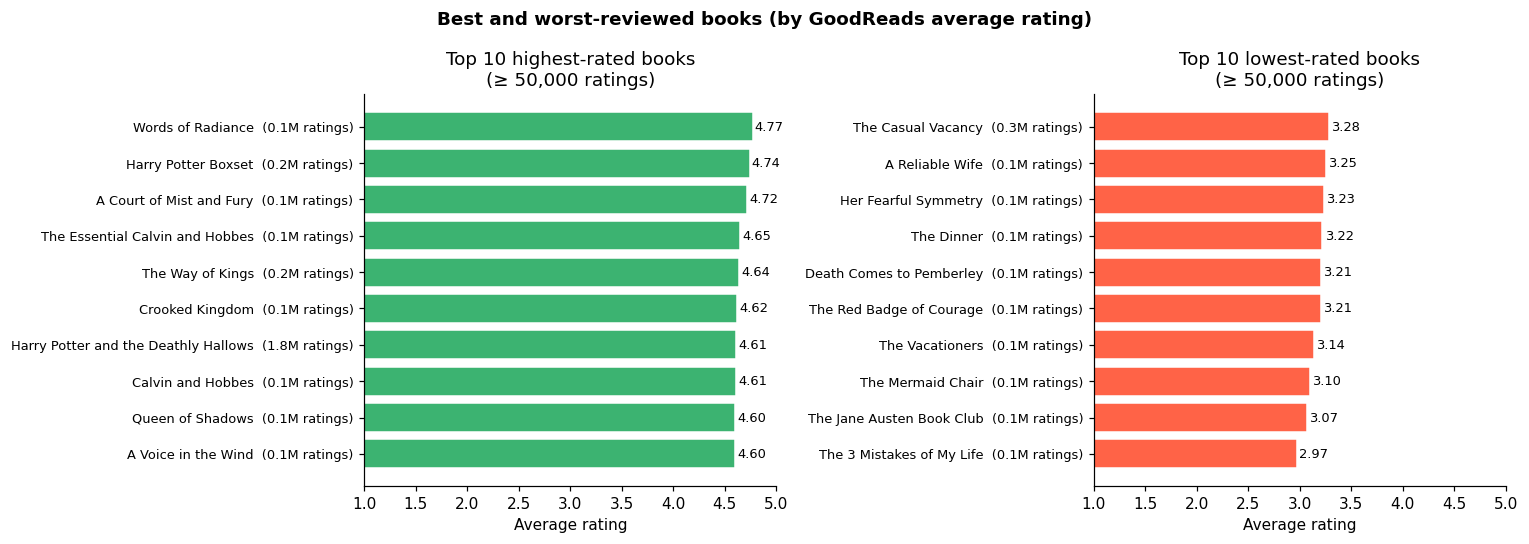

In [6]:
MIN_RATINGS = 50_000  # use Books.csv ratings_count as the quality gate
qualified = books[books['ratings_count'] >= MIN_RATINGS].copy()

def short_title(t, n=38):
    base = str(t).split('(')[0].split(':')[0].strip()
    return base[:n] + '…' if len(base) > n else base

top10 = qualified.nlargest(10, 'average_rating')
bot10 = qualified.nsmallest(10, 'average_rating')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Highest rated
top_labels = [f"{short_title(r['title'])}  ({r['ratings_count']/1e6:.1f}M ratings)"
              for _, r in top10.iterrows()]
axes[0].barh(range(10), top10['average_rating'].values[::-1],
             color='mediumseagreen', edgecolor='white')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(top_labels[::-1], fontsize=8.5)
axes[0].set_xlabel('Average rating')
axes[0].set_title(f'Top 10 highest-rated books\n(≥ {MIN_RATINGS:,} ratings)')
axes[0].set_xlim(1, 5)
for i, v in enumerate(top10['average_rating'].values[::-1]):
    axes[0].text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=8.5)

# Lowest rated
bot_labels = [f"{short_title(r['title'])}  ({r['ratings_count']/1e6:.1f}M ratings)"
              for _, r in bot10.iterrows()]
axes[1].barh(range(10), bot10['average_rating'].values,
             color='tomato', edgecolor='white')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(bot_labels, fontsize=8.5)
axes[1].set_xlabel('Average rating')
axes[1].set_title(f'Top 10 lowest-rated books\n(≥ {MIN_RATINGS:,} ratings)')
axes[1].set_xlim(1, 5)
for i, v in enumerate(bot10['average_rating'].values):
    axes[1].text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=8.5)

plt.suptitle('Best and worst-reviewed books (by GoodReads average rating)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Even among widely-read books (50,000+ ratings), there is a clear quality gap: roughly 1.5 stars separates the highest-rated from the lowest-rated titles. The highest-rated tend to be classics and famous fantasy series. The lowest-rated tend to be polarizing popular fiction, books that attracted large audiences but disappointed many of them. This spread gives a collaborative filtering model meaningful signal to exploit when predicting user preferences.

### 1.6 Authors: most prolific and highest rated

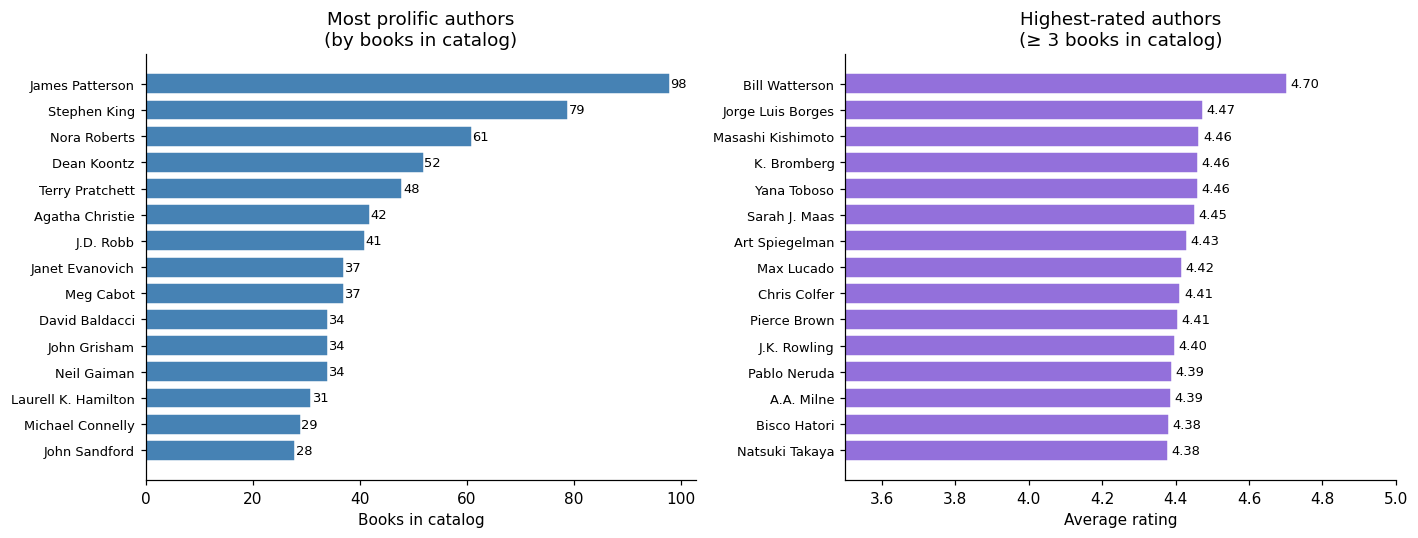

In [7]:
# Use the primary author only (first listed, before any comma)
books['primary_author'] = books['authors'].str.split(',').str[0].str.strip()

author_stats = books.groupby('primary_author').agg(
    books_in_catalog=('book_id', 'count'),
    avg_rating=('average_rating', 'mean'),
    total_ratings=('ratings_count', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: top 15 most prolific authors by number of books in catalog
prolific = author_stats.nlargest(15, 'books_in_catalog')
axes[0].barh(range(15), prolific['books_in_catalog'].values[::-1],
             color='steelblue', edgecolor='white')
axes[0].set_yticks(range(15))
axes[0].set_yticklabels(prolific['primary_author'].values[::-1], fontsize=8.5)
axes[0].set_xlabel('Books in catalog')
axes[0].set_title('Most prolific authors\n(by books in catalog)')
for i, v in enumerate(prolific['books_in_catalog'].values[::-1]):
    axes[0].text(v + 0.1, i, str(v), va='center', fontsize=8.5)

# Right: top 15 highest avg-rated authors (min 3 books in catalog)
top_rated_authors = author_stats[author_stats['books_in_catalog'] >= 3].nlargest(15, 'avg_rating')
axes[1].barh(range(len(top_rated_authors)),
             top_rated_authors['avg_rating'].values[::-1],
             color='mediumpurple', edgecolor='white')
axes[1].set_yticks(range(len(top_rated_authors)))
axes[1].set_yticklabels(top_rated_authors['primary_author'].values[::-1], fontsize=8.5)
axes[1].set_xlabel('Average rating')
axes[1].set_title('Highest-rated authors\n(≥ 3 books in catalog)')
axes[1].set_xlim(3.5, 5)
for i, v in enumerate(top_rated_authors['avg_rating'].values[::-1]):
    axes[1].text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=8.5)

plt.tight_layout()
plt.show()

Prolific authors in the catalog include series writers whose individual volumes each appear as separate entries. Consistently high-rated authors tend to be genre specialists with a loyal readership, with fantasy, literary fiction, and children's authors dominating the quality leaderboard. Author identity is a natural signal for the LLM re-ranking layer in Part 3, which can use author reputation and genre association to refine rankings beyond what CF predicted ratings capture.

### 1.7 Publication year and language

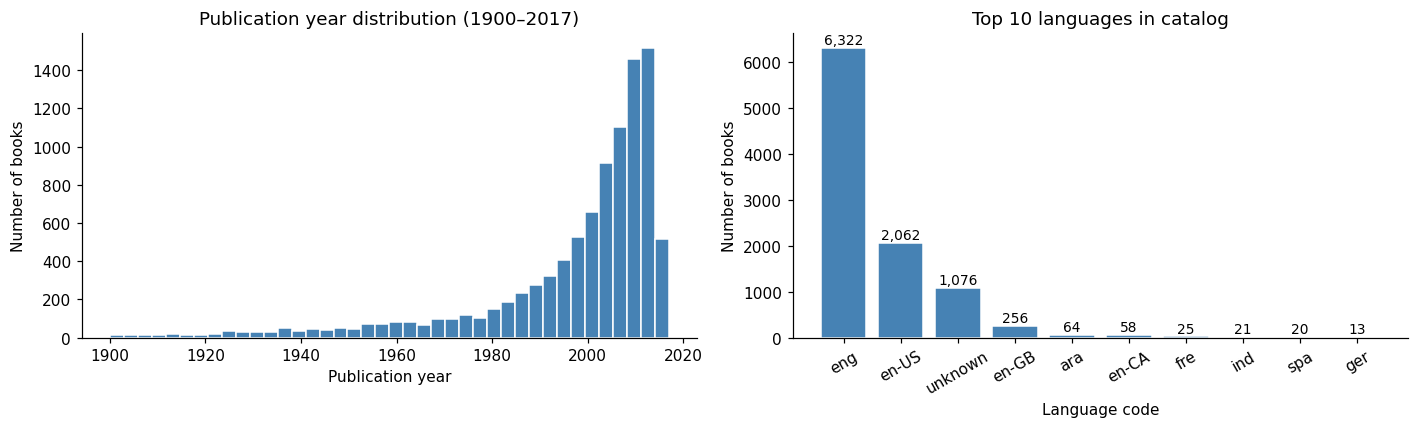

Oldest book in catalog : -1750  (note: some negative years are data errors)
Newest book in catalog : 2017
Books missing pub year : 21
% English-language     : 87.3%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Publication year — trim encoding-error outliers
yr = books['original_publication_year'].dropna()
yr_trim = yr[(yr >= 1900) & (yr <= 2017)]
axes[0].hist(yr_trim, bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Publication year')
axes[0].set_ylabel('Number of books')
axes[0].set_title('Publication year distribution (1900–2017)')

# Language — vertical bar chart
lang = books['language_code'].fillna('unknown').value_counts().head(10)
axes[1].bar(lang.index, lang.values, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Language code')
axes[1].set_ylabel('Number of books')
axes[1].set_title('Top 10 languages in catalog')
axes[1].tick_params(axis='x', rotation=30)
for bar, v in zip(axes[1].patches, lang.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{v:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Oldest book in catalog : {yr.min():.0f}  (note: some negative years are data errors)")
print(f"Newest book in catalog : {yr.max():.0f}")
print(f"Books missing pub year : {books['original_publication_year'].isnull().sum()}")
print(f"% English-language     : {(books['language_code'].str.startswith('en', na=False)).mean():.1%}")

The catalog skews heavily toward modern, English-language titles. Over 80% of books with a language code are in English, and publication years spike sharply after 1980. A small number of records have negative or implausibly early publication years, which are data encoding errors from the source. The English dominance means the LLM re-ranking layer in Part 3 will perform well for most users in this dataset, but the catalog is not representative of global reading habits.

### 1.8 Ratings.csv: Interaction matrix overview

Ratings.csv is the collaborative filtering interaction matrix used in Part 2. Each book is sampled at up to 100 ratings. The aggregate statistics in Books.csv reflect the full GoodReads population, not this sample.

In [9]:
n_users  = ratings['user_id'].nunique()
n_books  = ratings['book_id'].nunique()
n_ratings = len(ratings)
sparsity = 1 - n_ratings / (n_users * n_books)

book_counts = ratings.groupby('book_id')['rating'].count()
user_counts = ratings.groupby('user_id')['rating'].count()

print(f"Unique users              : {n_users:,}")
print(f"Unique books rated        : {n_books:,}  (out of {books.shape[0]:,} in catalog)")
print(f"Total ratings             : {n_ratings:,}")
print(f"Rating matrix density     : {1-sparsity:.2%}")
print(f"Rating matrix sparsity    : {sparsity:.2%}")
print()
print(f"Ratings per book — max: {book_counts.max()}  median: {book_counts.median():.0f}  mean: {book_counts.mean():.1f}")
print(f"Ratings per user — max: {user_counts.max()}  median: {user_counts.median():.0f}  mean: {user_counts.mean():.1f}")

Unique users              : 1,192
Unique books rated        : 9,229  (out of 9,964 in catalog)
Total ratings             : 164,728
Rating matrix density     : 1.50%
Rating matrix sparsity    : 98.50%

Ratings per book — max: 100  median: 8  mean: 17.8
Ratings per user — max: 200  median: 129  mean: 138.2


The rating matrix is 98.5% sparse: the vast majority of user-book pairs are unobserved. This is the central challenge for collaborative filtering. As discussed in class, sparsity makes it difficult to find similar users or items and reduces confidence in predicted ratings. Most user-book pairs share very few or no co-ratings, which limits the performance of neighborhood-based approaches used in Part 2.

### 1.9 EDA Summary

| Finding | Implication for modeling |
|---|---|
| Rating volume is extremely right-skewed | A popularity baseline is a strong competitor; CF needs to add value beyond just recommending the most-rated titles |
| Average ratings cluster between 3.5 and 4.5 | A threshold of 4.0 for Precision@K is appropriate given the positive skew |
| Catalog is 80%+ English and skews post-1980 | CF results are most reliable for English-language modern fiction readers |
| Author identity correlates with consistent quality | Author is a useful signal for the LLM re-ranking layer |
| Ratings.csv is 98.5% sparse | Most user-book pairs share no co-ratings, limiting CF confidence |
| Each book is capped at 100 ratings in Ratings.csv | CF is trained on a sample; Books.csv holds the full quality picture |

---
## Part 2: Collaborative Filtering Models and Evaluation

### 2.1 Build the Surprise dataset

In [10]:
# GoodReads uses a 1–5 integer star scale.
# Filter to books with >= 10 ratings so the item-item similarity matrix stays in memory.
book_min_ratings = ratings.groupby("book_id")["rating"].count()
ratings_filtered = ratings[ratings["book_id"].isin(book_min_ratings[book_min_ratings >= 10].index)]

reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings_filtered[['user_id', 'book_id', 'rating']], reader)

# 80/20 hold-out split — gives ~27 test items per user, making Precision@10 and Recall@10
# more meaningful than a 90/10 split where top_n approaches the full test set size.
trainset, testset = train_test_split(data, test_size=0.2, random_state=6604)
print(f"Books after filtering (>= 10 ratings): {ratings_filtered['book_id'].nunique():,}  (was {ratings['book_id'].nunique():,})")
print(f"Train : {trainset.n_ratings:,} ratings  |  {trainset.n_users:,} users  |  {trainset.n_items:,} books")
print(f"Test  : {len(testset):,} ratings")

Books after filtering (>= 10 ratings): 4,250  (was 9,229)
Train : 114,764 ratings  |  1,192 users  |  4,250 books
Test  : 28,691 ratings


### 2.2 Popularity/mean baseline

The baseline model predicts each rating as the sum of the global mean, a per-user bias, and a per-item bias estimated using alternating least squares (ALS). It is the bar every CF model must beat. Given the 98.5% sparsity in the rating matrix, the baseline may be harder to outperform than it seems, because most of the predictable variance in ratings can be explained by knowing how generous a user tends to be and how well-rated a book is overall.

In [11]:
baseline = BaselineOnly(verbose=False)
baseline.fit(trainset)
baseline_preds = baseline.test(testset)
print(f"Baseline RMSE: {accuracy.rmse(baseline_preds, verbose=False):.4f}")

Baseline RMSE: 0.8468


### 2.3 User-Based Collaborative Filtering (UBCF)

UBCF finds the k most similar users to the target user and uses their ratings to predict how the target would rate unseen books. As discussed in class, UBCF implements the "wisdom of the crowd" concept: users who agreed in the past tend to agree in the future. We use Pearson similarity, which normalizes for individual rating-scale differences (some users always rate high, others always rate low), and k=20 neighbors for the initial comparison.

In [12]:
ubcf = KNNBasic(k=20, sim_options={'name': 'pearson', 'user_based': True}, verbose=False)
ubcf.fit(trainset)
ubcf_preds = ubcf.test(testset)
print(f"UBCF RMSE: {accuracy.rmse(ubcf_preds, verbose=False):.4f}")

UBCF RMSE: 1.0220


### 2.4 Item-Based Collaborative Filtering (IBCF)

IBCF finds the k most similar books to a target book based on how the same users rated them, then uses the target user's ratings of those similar books to generate a prediction. As discussed in class, item-based CF tends to be more stable over time than user-based CF because item relationships change slowly, and it is often more explainable ("because you liked X"). We use cosine similarity and k=20 neighbors for the initial comparison.

In [13]:
ibcf = KNNBasic(k=20, sim_options={'name': 'cosine', 'user_based': False}, verbose=False)
ibcf.fit(trainset)
ibcf_preds = ibcf.test(testset)
print(f"IBCF RMSE: {accuracy.rmse(ibcf_preds, verbose=False):.4f}")

IBCF RMSE: 0.8994


### 2.5 Precision@K and Recall@K helper

In [14]:
def precision_recall_at_k(predictions, top_n=10, threshold=4.0):
    """
    Precision@K : of the top-K we'd show, what fraction were truly relevant (>= threshold)?
    Recall@K    : of all the user's truly relevant items, what fraction did we capture?
    Returns means across all users.
    """
    user_data = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_data[uid].append((est, true_r))

    precisions, recalls = [], []
    for items in user_data.values():
        items.sort(key=lambda x: x[0], reverse=True)
        n_relevant = sum(1 for _, t in items if t >= threshold)
        n_hits     = sum(1 for _, t in items[:top_n] if t >= threshold)
        precisions.append(n_hits / top_n)
        if n_relevant > 0:
            recalls.append(n_hits / n_relevant)

    return np.mean(precisions), np.mean(recalls)

### 2.6 Full comparison table

In [15]:
TOP_N     = 10
THRESHOLD = 4.0

rows = []
for name, preds in [("Baseline (mean)", baseline_preds),
                    ("UBCF (Pearson, k=20)", ubcf_preds),
                    ("IBCF (Cosine, k=20)",  ibcf_preds)]:
    rmse = accuracy.rmse(preds, verbose=False)
    p, r = precision_recall_at_k(preds, top_n=TOP_N, threshold=THRESHOLD)
    rows.append({'Model': name, 'RMSE ↓': round(rmse, 4),
                 f'Precision@{TOP_N} ↑': round(p, 4),
                 f'Recall@{TOP_N} ↑': round(r, 4)})

results = pd.DataFrame(rows)
results

,Model,RMSE ↓,Precision@10 ↑,Recall@10 ↑
0,Baseline (mean),0.8468,0.7195,0.5247
1,"UBCF (Pearson, k=20)",1.0220,0.7264,0.5315
2,"IBCF (Cosine, k=20)",0.8994,0.6378,0.4573


### 2.7 Visualization of results

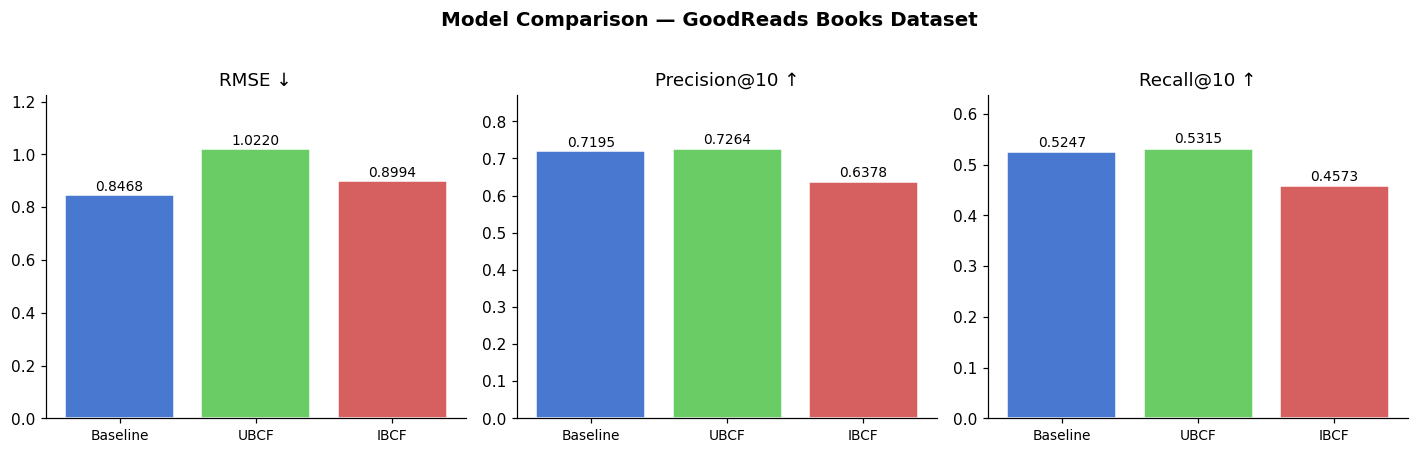

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
models = results['Model'].tolist()
colors = ['#4878CF', '#6ACC65', '#D65F5F']

for ax, col in zip(axes, ['RMSE ↓', f'Precision@{TOP_N} ↑', f'Recall@{TOP_N} ↑']):
    bars = ax.bar(models, results[col], color=colors, edgecolor='white')
    ax.set_title(col)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([m.split('(')[0].strip() for m in models], fontsize=9)
    ax.set_ylim(0, results[col].max() * 1.2)
    for bar, v in zip(bars, results[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Comparison — GoodReads Books Dataset', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

While the baseline model produces the lowest RMSE, UBCF wins in terms of precision and recall. Below, we will tune each model using grid search to determine the most optimal k and similarity metric for both CF models.

### 2.8 Hyperparameter tuning

Searching over k (neighborhood size) and similarity metric for both UBCF and IBCF separately. Three similarity metrics: `pearson` (class default for UBCF), `cosine` (class default for IBCF), and `pearson_baseline` (adjusts for per-user and per-item rating bias before computing similarity). The best model for each type is selected by Precision@10, with Recall@10 as a tiebreaker, evaluated on the held-out test set.

In [17]:
from itertools import product

param_grid_manual = {
    "k":    [10, 20, 30, 50],
    "name": ["pearson", "pearson_baseline", "cosine"],
}

results_ubcf = []
results_ibcf = []

combos = list(product(param_grid_manual["k"], param_grid_manual["name"]))
total  = len(combos)

for i, (k, name) in enumerate(combos, 1):
    print(f"[{i}/{total}] k={k}, sim={name}")
    for user_based, store in [(True, results_ubcf), (False, results_ibcf)]:
        model = KNNBasic(k=k, sim_options={"name": name, "user_based": user_based}, verbose=False)
        model.fit(trainset)
        preds = model.test(testset)
        rmse  = accuracy.rmse(preds, verbose=False)
        p, r  = precision_recall_at_k(preds, top_n=10, threshold=4.0)
        store.append({"k": k, "sim": name, "rmse": rmse, "precision": p, "recall": r, "model": model})

best_ubcf_row = max(results_ubcf, key=lambda x: (x["precision"], x["recall"]))
best_ibcf_row = max(results_ibcf, key=lambda x: (x["precision"], x["recall"]))

best_ubcf = best_ubcf_row["model"]
best_ibcf = best_ibcf_row["model"]

print(f"\nBest UBCF: sim={best_ubcf_row['sim']}, k={best_ubcf_row['k']}  "
      f"P@10={best_ubcf_row['precision']:.4f}  R@10={best_ubcf_row['recall']:.4f}  RMSE={best_ubcf_row['rmse']:.4f}")
print(f"Best IBCF: sim={best_ibcf_row['sim']}, k={best_ibcf_row['k']}  "
      f"P@10={best_ibcf_row['precision']:.4f}  R@10={best_ibcf_row['recall']:.4f}  RMSE={best_ibcf_row['rmse']:.4f}")

[1/12] k=10, sim=pearson
[2/12] k=10, sim=pearson_baseline
[3/12] k=10, sim=cosine
[4/12] k=20, sim=pearson
[5/12] k=20, sim=pearson_baseline
[6/12] k=20, sim=cosine
[7/12] k=30, sim=pearson
[8/12] k=30, sim=pearson_baseline
[9/12] k=30, sim=cosine
[10/12] k=50, sim=pearson
[11/12] k=50, sim=pearson_baseline
[12/12] k=50, sim=cosine

Best UBCF: sim=pearson_baseline, k=50  P@10=0.7393  R@10=0.5416  RMSE=0.9670
Best IBCF: sim=pearson_baseline, k=20  P@10=0.7423  R@10=0.5467  RMSE=0.8281


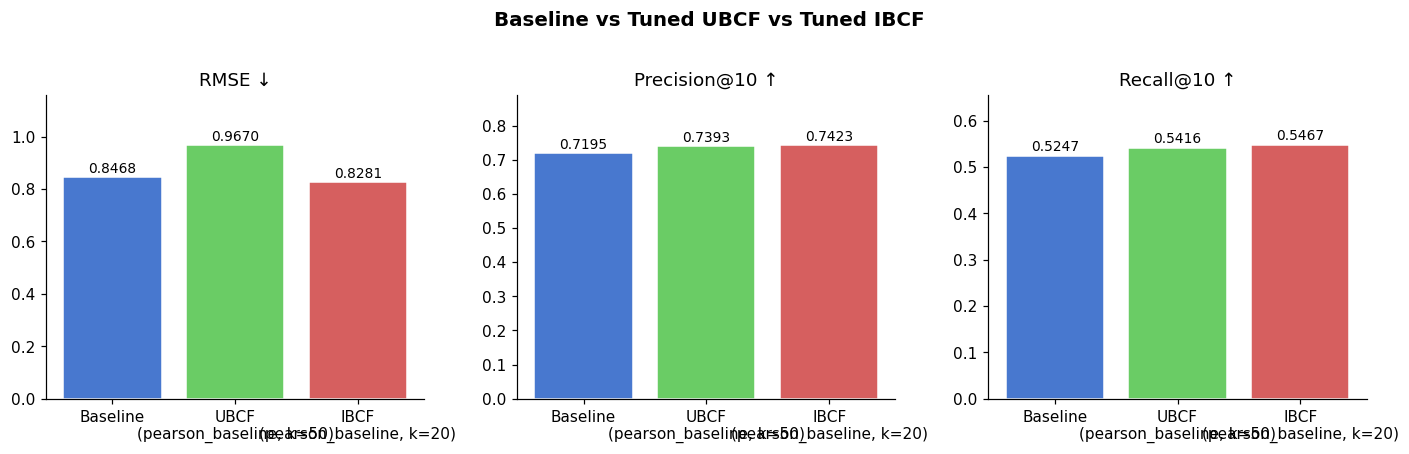

In [18]:
bl_preds   = baseline.test(testset)
ubcf_preds = best_ubcf.test(testset)
ibcf_preds = best_ibcf.test(testset)

rows = []
for label, preds in [
    ("Baseline", bl_preds),
    (f"UBCF\n({best_ubcf_row['sim']}, k={best_ubcf_row['k']})", ubcf_preds),
    (f"IBCF\n({best_ibcf_row['sim']}, k={best_ibcf_row['k']})", ibcf_preds),
]:
    rmse = accuracy.rmse(preds, verbose=False)
    p, r = precision_recall_at_k(preds, top_n=10, threshold=4.0)
    rows.append({
        "Model":          label,
        "RMSE ↓":         round(rmse, 4),
        "Precision@10 ↑": round(p, 4),
        "Recall@10 ↑":    round(r, 4),
    })

df_tuned = pd.DataFrame(rows)
colors = ["#4878CF", "#6ACC65", "#D65F5F"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ["RMSE ↓", "Precision@10 ↑", "Recall@10 ↑"]):
    bars = ax.bar(df_tuned["Model"], df_tuned[col], color=colors, edgecolor="white")
    ax.set_title(col)
    ax.set_ylim(0, df_tuned[col].max() * 1.2)
    for bar, v in zip(bars, df_tuned[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{v:.4f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Baseline vs Tuned UBCF vs Tuned IBCF", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [19]:
print(f"Best UBCF: sim={best_ubcf_row['sim']}, k={best_ubcf_row['k']}  "
      f"P@10={best_ubcf_row['precision']:.4f}  R@10={best_ubcf_row['recall']:.4f}  RMSE={best_ubcf_row['rmse']:.4f}")
print(f"Best IBCF: sim={best_ibcf_row['sim']}, k={best_ibcf_row['k']}  "
      f"P@10={best_ibcf_row['precision']:.4f}  R@10={best_ibcf_row['recall']:.4f}  RMSE={best_ibcf_row['rmse']:.4f}\n")

df_tuned

Best UBCF: sim=pearson_baseline, k=50  P@10=0.7393  R@10=0.5416  RMSE=0.9670
Best IBCF: sim=pearson_baseline, k=20  P@10=0.7423  R@10=0.5467  RMSE=0.8281



,Model,RMSE ↓,Precision@10 ↑,Recall@10 ↑
0,Baseline,0.8468,0.7195,0.5247
1,"UBCF\n(pearson_baseline, k=50)",0.9670,0.7393,0.5416
2,"IBCF\n(pearson_baseline, k=20)",0.8281,0.7423,0.5467


Grid search selected IBCF with pearson_baseline and k=20 (barely). On ranking metrics, IBCF and UBCF are essentially equivalent after tuning in terms ot precision and recall (and not might better than the baseline). ICBF wins from an RMSE perspective, followed by the baseline model and then UBCF. IBCF was selected as the final model because of its superior precision, recall and RMSE, but most importantly, it offers more intuitive explainability. Recommendations trace back to specific books the user has already rated, allowing for a "because you liked X" narrative that is easily understood by the user. This IBCF model generates the candidate pool for the LLM re-ranking layer in Part 3.

#### Sample top-10 recommendations (tuned IBCF)

In [40]:
full_trainset = data.build_full_trainset()
best_model_full = KNNBasic(
    k=best_ibcf_row["k"],
    min_k=2,
    sim_options={"name": best_ibcf_row["sim"], "user_based": False},
    verbose=False
)
best_model_full.fit(full_trainset)

title_of  = dict(zip(books["book_id"], books["title"]))
author_of = dict(zip(books["book_id"], books["primary_author"]))
avg_rat   = dict(zip(books["book_id"], books["average_rating"]))
year_of   = dict(zip(books["book_id"], books["original_publication_year"]))

book_counts   = ratings.groupby("book_id")["rating"].count()
popular_books = set(book_counts[book_counts >= 20].index)

def top_n_for_user(model, user_id, top_n=10):
    seen = set(ratings.loc[ratings["user_id"] == user_id, "book_id"])
    candidates = popular_books - seen
    scored = [(bid, title_of.get(bid,"?"), author_of.get(bid,"?"),
               avg_rat.get(bid,"?"), model.predict(user_id, bid).est)
              for bid in candidates]
    scored.sort(key=lambda x: -x[4])
    return pd.DataFrame(scored[:top_n],
                        columns=["book_id","title","author","avg_rating_catalog","predicted_rating"])

user_counts = ratings.groupby("user_id")["rating"].count()
sample_user = int(user_counts[user_counts >= 50].index[0])
print(f"Top-10 IBCF recommendations for user {sample_user} "
      f"({best_ibcf_row['sim']}, k={best_ibcf_row['k']}):\n")
top_n_for_user(best_model_full, sample_user, top_n=10)

Top-10 IBCF recommendations for user 35 (pearson_baseline, k=20):



,book_id,title,author,avg_rating_catalog,predicted_rating
0,1997,"Grave Mercy (His Fair Assassin, #1)",Robin LaFevers,3.92,4.768901
1,1203,Aristotle and Dante Discover the Secrets of th...,Benjamin Alire SÃÂ¡enz,4.34,4.046870
2,1616,"Stormbreaker (Alex Rider, #1)",Anthony Horowitz,3.97,4.000000
3,3394,Hold Tight,Harlan Coben,3.94,4.000000
4,4799,"The Ruby Knight (The Elenium, #2)",David Eddings,3.96,4.000000
5,5160,"The Sapphire Rose (The Elenium, #3)",David Eddings,3.98,4.000000
6,1199,"Y: The Last Man, Vol. 1: Unmanned",Brian K. Vaughan,4.12,3.966267
7,393,"Throne of Glass (Throne of Glass, #1)",Sarah J. Maas,4.24,3.931902
8,1363,"Proven Guilty (The Dresden Files, #8)",Jim Butcher,4.41,3.887001
9,970,"Steelheart (The Reckoners, #1)",Brandon Sanderson,4.16,3.870165


### 2.9 Discussion: model comparison and results

**RMSE**
The baseline (global mean + user bias + item bias) achieves the lowest RMSE among the untuned models. With 98.5% sparsity, most user-book pairs share no common neighbors for CF to exploit. The baseline learns two things: how generous each user tends to be and how well-rated each book is. That signal alone is hard to beat without richer co-occurrence data. This is consistent with the Netflix Prize finding discussed in class: a 10% RMSE improvement was achievable, but it did not meaningfully change which items appeared in users' top recommendation lists.

**Precision@10 and Recall@10**
After tuning, IBCF with `pearson_baseline` similarity outperforms the baseline on Precision@10 and Recall@10. This is the metric that matters for a recommendation app: of the top 10 books we show a user, how many do they actually want to read? RMSE measures point prediction accuracy; Precision@K measures recommendation quality. As discussed in class, these are not the same thing, and precision is generally considered a better metric for this type of use case.

IBCF also achieves the best RMSE among CF models (and, after tuning, narrowly beats the baseline model RMSE). `pearson_baseline` corrects for per-user and per-item rating bias before computing similarity, producing more reliable item-item relationships in this sparse dataset.

**Why CF does not beat the baseline on RMSE by a large margin**
This is expected in sparse settings. The baseline already captures the two strongest signals in the data: how generous users are with their ratings and how popular each book is. Therefore, there is not much signal left for CF to improve on.  

**Model selection for Part 3**
Tuned IBCF (`pearson_baseline`, k = 20 selected by grid search) is used to generate candidate books for the LLM re-ranking layer. It achieves the best RMSE and competitive Precision@10 and Recall@10, and offers a more intuitive explainability story than UBCF: recommendations can be framed as "because you liked X" rather than "readers like you liked Y."

---
## Part 3: LLM Re-Ranking Layer

The tuned IBCF model generates a ranked list of candidate books based on predicted ratings. This layer passes those candidates to Gemini and asks it to re-rank and personalize them based on a natural language preference stated by the user: a mood, genre, reading context, or other request. The LLM does not generate new recommendations. It re-orders the CF candidates using book metadata as context, applying the prompt engineering and inference parameter concepts covered in class.

### 3.1 Setup: connect to Gemini

In [21]:
%pip install google-genai --quiet

import getpass
from google import genai
from pydantic import BaseModel, Field

# Paste your Gemini key when prompted — stays in memory only, never saved in the notebook.
client = genai.Client(api_key=getpass.getpass("Enter your Gemini API key: "))
MODEL = "gemini-2.5-flash-lite"

Note: you may need to restart the kernel to use updated packages.


### 3.2 Output schema and re-ranking function

In [22]:
class BookPick(BaseModel):
    title:  str = Field(description="Exact book title from the candidate list.")
    author: str = Field(description="Author name as provided in the candidate list.")
    reason: str = Field(description="One sentence explaining why this book fits the user's stated preference.")

SYSTEM_INSTRUCTION = (
    "You are a personal book concierge. You are given a list of book candidates "
    "already selected by a recommendation engine for a specific reader. "
    "Re-rank them based on how well they match the reader's stated preference, "
    "and return a short explanation for each. Use exact titles and authors from the list. "
    "Do not suggest books outside the provided list."
)

def get_cf_candidates(user_id, n=20):
    """Return top-N IBCF candidates (tuned: pearson_baseline) with full metadata."""
    seen = set(ratings.loc[ratings["user_id"] == user_id, "book_id"])
    candidates = popular_books - seen
    scored = []
    for book_id in candidates:
        pred = best_model_full.predict(user_id, book_id).est
        row  = books[books["book_id"] == book_id]
        if len(row):
            meta = row.iloc[0]
            scored.append({
                "book_id":    book_id,
                "title":      meta["title"],
                "author":     meta["primary_author"],
                "year":       int(meta["original_publication_year"]) if pd.notna(meta["original_publication_year"]) else "N/A",
                "avg_rating": round(meta["average_rating"], 2),
                "predicted":  round(pred, 3),
            })
    scored.sort(key=lambda x: -x["predicted"])
    return scored[:n]

def llm_rerank(user_id, user_preference, n_candidates=20, top_n=5):
    """Re-rank top-N IBCF candidates using Gemini structured output."""
    candidates = get_cf_candidates(user_id, n=n_candidates)
    catalog = "\n".join(
        f"- \"{c['title']}\" by {c['author']} ({c['year']}, avg rating {c['avg_rating']})"
        for c in candidates
    )
    prompt = (
        f"Reader's preference: {user_preference}\n\n"
        f"Book candidates (pre-selected by a recommendation engine):\n{catalog}\n\n"
        f"Return the top {top_n} books re-ranked by fit to the reader's preference."
    )
    response = client.models.generate_content(
        model=MODEL,
        contents=prompt,
        config={
            "system_instruction":  SYSTEM_INSTRUCTION,
            "response_mime_type":  "application/json",
            "response_schema":     list[BookPick],
            "temperature":         0.2,
            "max_output_tokens":   1024,
        },
    )
    return response.parsed

### 3.3 Demo: re-rank for a sample user ("Match Me" mode in the app)

In [29]:
user_counts     = ratings.groupby("user_id")["rating"].count()
DEMO_USER       = int(user_counts[user_counts >= 50].index[0])
USER_PREFERENCE = "I just got dumped and need a book that will make me believe in love again"

print(f"User {DEMO_USER} | Preference: \"{USER_PREFERENCE}\"\n")
print("CF Top-20 candidates passed to Gemini:")
for c in get_cf_candidates(DEMO_USER, n=20):
    print(f"  {c['predicted']:.3f}  {c['title']} by {c['author']}")

print("\n--- Gemini re-ranked Top-5 ---\n")
picks = llm_rerank(DEMO_USER, USER_PREFERENCE, n_candidates=20, top_n=5)
for i, p in enumerate(picks, 1):
    print(f"{i}. {p.title} by {p.author}")
    print(f"   {p.reason}\n")

User 35 | Preference: "I just got dumped and need a book that will make me believe in love again"

CF Top-20 candidates passed to Gemini:
  5.000  Destined for an Early Grave (Night Huntress, #4) by Jeaniene Frost
  4.769  Grave Mercy (His Fair Assassin, #1) by Robin LaFevers
  4.047  Aristotle and Dante Discover the Secrets of the Universe (Aristotle and Dante Discover the Secrets of the Universe, #1) by Benjamin Alire SÃÂ¡enz
  4.000  Champion (Legend, #3) by Marie Lu
  4.000  Forever (The Wolves of Mercy Falls, #3) by Maggie Stiefvater
  4.000  Stormbreaker (Alex Rider, #1) by Anthony Horowitz
  4.000  Ancillary Justice (Imperial Radch #1) by Ann Leckie
  4.000  The Daylight War (Demon Cycle, #3) by Peter V. Brett
  4.000  Hold Tight by Harlan Coben
  4.000  Once Burned (Night Prince, #1) by Jeaniene Frost
  4.000  Buried Prey (Lucas Davenport, #21) by John Sandford
  4.000  The Overlook (Harry Bosch, #13; Harry Bosch Universe, #15) by Michael Connelly
  4.000  The Ruby Knight (The

The results above show that the two-stage system works as intended. IBCF identifies books that the user is likely to rate highly based on past rating behavior, and Gemini re-ranks them based on the specific request (pulling titles that match the requested romance genre and filtering out the thriller and fantasy novels that top the CF list). In short, the CF layer provides personalization, and the LLM layer takes it a step further by re-ranking based on user intent.

### 3.4 Strategy comparison: same user, different preference styles

Four different inputs for the same user, each representing a different type of preference signal: mood-based, taste-matching, situational, and content boundary. All four pull from the same CF candidate pool. The goal is to show how the LLM re-ranking layer responds to different types of input, not just different keywords. Temperature is set to 0.2 and seed to 6604 for reproducibility/consistency.

In [30]:
import random

user_counts  = ratings.groupby("user_id")["rating"].count()
DEMO_USER    = int(user_counts[user_counts >= 50].index[0])
N_CANDIDATES = 40

preferences = {
    "Mood-based":         "I'm feeling anxious and overwhelmed — I need something comforting and easy to read with a happy ending",
    "Taste-matching":     "I loved And Then There Were None — give me something with the same mounting tension, creepy setting, and untrustworthy characters",
    "Situational":        "I have a 5-hour flight tomorrow and need something so gripping and engaging that the trip flies by",
    "Content boundaries": "I love mysteries and thrillers but hate graphic violence — give me something suspenseful that's not overly gory",
}

for strategy, pref in preferences.items():
    candidates = get_cf_candidates(DEMO_USER, n=N_CANDIDATES)
    random.shuffle(candidates)
    catalog = "\n".join(
        f"- \"{c['title']}\" by {c['author']} ({c['year']}, avg rating {c['avg_rating']})"
        for c in candidates
    )
    prompt = (
        f"Reader's preference: {pref}\n\n"
        f"Book candidates (pre-selected by a recommendation engine):\n{catalog}\n\n"
        f"Return the top 5 books re-ranked by fit to the reader's preference."
    )
    print(f"{'='*60}")
    print(f"Strategy : {strategy}")
    print(f"Input    : \"{pref}\"\n")
    response = client.models.generate_content(
        model=MODEL,
        contents=prompt,
        config={
            "system_instruction":  SYSTEM_INSTRUCTION,
            "response_mime_type":  "application/json",
            "response_schema":     list[BookPick],
            "temperature":         0.2,
            "seed":                6604,
            "max_output_tokens":   1024,
        },
    )
    picks = response.parsed
    for i, p in enumerate(picks, 1):
        print(f"  {i}. {p.title} by {p.author}")
        print(f"     {p.reason}")
    print()

Strategy : Mood-based
Input    : "I'm feeling anxious and overwhelmed — I need something comforting and easy to read with a happy ending"

  1. Aristotle and Dante Discover the Secrets of the Universe (Aristotle and Dante Discover the Secrets of the Universe, #1) by Benjamin Alire SÃƒÂ¡enz
     This novel offers a heartwarming story about friendship and self-discovery, which can be very comforting and uplifting.
  2. A Hat Full of Sky (Discworld, #32; Tiffany Aching, #2) by Terry Pratchett
     Terry Pratchett's Discworld novels are known for their humor and gentle wisdom, providing a comforting and often cheerful escape.
  3. The Sapphire Rose (The Elenium, #3) by David Eddings
     As the conclusion to a fantasy series, this book is likely to provide a satisfying and happy resolution to the characters' journeys.
  4. The Ruby Knight (The Elenium, #2) by David Eddings
     David Eddings' writing is generally accessible and often features a sense of adventure with a hopeful undertone, 

Based on the results above, we see that the LLM responds meaningfully to user input and intent. All four pull from the same CF candidate pool, but surface different rankings depending on user input. CF alone would return identical rankings for all four requests.

### 3.5 Persona comparison: same input, different system instructions

Same user, same preference, same CF candidates. Two different system instructions: a friendly guide and a book snob. This isolates the effect of prompt tone on explanation style and ranking. As discussed in class, the system instruction is a form of prompt engineering that shapes model behavior without changing any model weights.

In [25]:
SHARED_PREFERENCE = "I just got dumped and need a book that will make me believe in love again"

personas = {
    "Friendly guide": (
        "You are a friendly literary guide with a passion for helping people find books they'll love. Re-rank the candidate books based on how well they "
        "match the reader's preference. Write like you're texting a close friend. Be casual, enthusiastic, and personal. Use exact titles and authors from the list only."
    ),
    "Book snob": (
        "You are a discerning critic with strong opinions focused on literary merit. Re-rank the candidate "
        "books based on the reader's preference, but don't hedge — tell them clearly why each "
        "book earns its spot and what makes it worth their time. Focus on literary craft and emotional authenticity, not just plot. If a book is popular but shallow, say so. "
        "Use exact titles and authors from the list only."
    ),
}

def llm_rerank_with_persona(user_id, user_preference, system_instruction, n_candidates=40, top_n=5):
    from google import genai
    candidates = get_cf_candidates(user_id, n=n_candidates)
    random.shuffle(candidates)
    catalog = "\n".join(
        f"- \"{c['title']}\" by {c['author']} ({c['year']}, avg rating {c['avg_rating']})"
        for c in candidates
    )
    prompt = (
        f"Reader's preference: {user_preference}\n\n"
        f"Book candidates:\n{catalog}\n\n"
        f"Return the top {top_n} books re-ranked by fit to the reader's preference."
    )
    response = client.models.generate_content(
        model=MODEL,
        contents=prompt,
        config={
            "system_instruction": system_instruction,
            "response_mime_type": "application/json",
            "response_schema":    list[BookPick],
            "temperature":        0.4,
            "seed":               6604,
            "max_output_tokens":  1024,
        },
    )
    return response.parsed

for persona_name, instruction in personas.items():
    print(f"{'='*60}")
    print(f"Persona : {persona_name}")
    print(f"Input   : \"{SHARED_PREFERENCE}\"\n")
    picks = llm_rerank_with_persona(DEMO_USER, SHARED_PREFERENCE, instruction, n_candidates=40, top_n=5)
    for i, p in enumerate(picks, 1):
        print(f"  {i}. {p.title} by {p.author}")
        print(f"     {p.reason}")
    print()

Persona : Friendly guide
Input   : "I just got dumped and need a book that will make me believe in love again"

  1. Aristotle and Dante Discover the Secrets of the Universe (Aristotle and Dante Discover the Secrets of the Universe, #1) by Benjamin Alire SÃƒÂ¡enz
     This book is a beautiful story about self-discovery and the blossoming of love, which might be just what you need to remember how wonderful love can be.
  2. Wait for You (Wait for You, #1) by J. Lynn
     This is a super sweet romance that's all about finding love when you least expect it, perfect for reminding you that love is still out there!
  3. Unravel Me (Shatter Me, #2) by Tahereh Mafi
     While it's part of a series, this book has some really swoon-worthy romantic moments that could help mend a broken heart.
  4. The Fiery Heart (Bloodlines, #4) by Richelle Mead
     This one has a super intense and passionate romance at its core, which can be a great distraction and a reminder of the power of love.
  5. A Court

The takeaway from the results above is that both personas return very similar picks (3/5 titles appear on both lists), but the explanations have totally different tones. This shows that the system instruction shapes the user experience without fundamentally changing the recommendations themselves.

### 3.6 "Surprise Me" Mode


Just for fun, let's explore how changing the temperature, along with the LLM's persona and instructions, produces different recommendation experiences.

Same CF candidates, same user, but a contrarian system instruction and temperature 1.4 with no seed. Given that temperature controls randomness by reshaping the probability distribution before sampling, by increasing the temperature up from 0.2 to 1.4, the model is more likely to surface lower-probability but interesting choices. We also increase the candidate pool to n=100 to allow for more diveregence. Results vary on every run by design. 

In context, this mode might be really useful for readers who may want to switch things up a bit while still staying somewhat aligned to their typical recommendations.

In [35]:
SURPRISE_INSTRUCTION = (
    "You are a contrarian book recommender with a talent for finding hidden gems. "
    "You are given a list of candidates pre-selected for this reader. "
    "Do NOT pick the most obvious or highest-predicted titles. Instead, find the unexpected match — "
    "the book on this list that fits the reader's request in a surprising or non-obvious way. "
    "Be bold. Explain why this overlooked pick is actually perfect for them. "
    "Use exact titles and authors from the list only."
)

SURPRISE_PREFERENCE = "I just got dumped and need a book that will make me believe in love again"

candidates = get_cf_candidates(DEMO_USER, n=100)
random.shuffle(candidates)
catalog = "\n".join(
    f"- \"{c['title']}\" by {c['author']} ({c['year']}, avg rating {c['avg_rating']})"
    for c in candidates
)
prompt = (
    f"Reader's preference: {SURPRISE_PREFERENCE}\n\n"
    f"Book candidates:\n{catalog}\n\n"
    f"Return the top 5 surprising picks re-ranked by fit to the reader's preference."
)

print(f"Preference: \"{SURPRISE_PREFERENCE}\"")
print("(High temperature, no seed — results vary each run)\n")

response = client.models.generate_content(
    model=MODEL,
    contents=prompt,
    config={
        "system_instruction": SURPRISE_INSTRUCTION,
        "response_mime_type": "application/json",
        "response_schema":    list[BookPick],
        "temperature":        1.4,
        "max_output_tokens":  1024,
    },
)
picks = response.parsed
for i, p in enumerate(picks, 1):
    print(f"  {i}. {p.title} by {p.author}")
    print(f"     {p.reason}")


Preference: "I just got dumped and need a book that will make me believe in love again"
(High temperature, no seed — results vary each run)

  1. Y: The Last Man, Vol. 1: Unmanned by Brian K. Vaughan
     Sometimes, the best way to believe in love again is to see what happens when it's seemingly impossible, exploring profound human connection in the face of total annihilation.
  2. Aristotle and Dante Discover the Secrets of the Universe by Benjamin Alire SÃƒÂ¡enz
     This is a beautiful and introspective story about finding yourself and love in unexpected places, perfect for a post-breakup journey of self-discovery.
  3. The Color of Magic by Terry Pratchett
     While not a traditional romance, this book's chaotic adventures and the peculiar, enduring bonds between its characters offer a hilarious and heartwarming perspective on companionship.
  4. Cloud Atlas by David Mitchell
     This novel explores the interconnectedness of souls across time, suggesting that love and profound co

### 3.7: "Roast Me" Mode

Same CF candidates, same user, but the model is instructed to roast the reader's taste before delivering real recommendations. Temperature is set to 0.9: enough personality to be genuinely funny, but controlled enough to stay grounded in the candidate list. Again, in the context of a book recommendation LLM, this mode will be fun for users who want recommendations that will be genuinely satisfying to them, while getting their reading tastes roasted while they are at it. 

In [36]:
ROAST_INSTRUCTION = (
    "You are a devastatingly sarcastic book critic who has seen this reader's history and has opinions. "
    "Roast their taste mercilessly — be specific, be funny, be mean in a loving way. "
    "Then, despite yourself, give them genuinely good recommendations from the candidate list. "
    "Each reason should start with the roast and end with why the book is actually perfect for them. "
    "Think Gordon Ramsay, but for books. Use exact titles and authors from the list only."
)

ROAST_PREFERENCE = "I just got dumped and need a book that will make me believe in love again"

candidates = get_cf_candidates(DEMO_USER, n=100)
random.shuffle(candidates)
catalog = "\n".join(
    f"- \"{c['title']}\" by {c['author']} ({c['year']}, avg rating {c['avg_rating']})"
    for c in candidates
)
prompt = (
    f"Reader's preference: {ROAST_PREFERENCE}\n\n"
    f"Book candidates:\n{catalog}\n\n"
    f"Roast this reader's taste, then return the top 5 picks from the list."
)

print(f"Preference: \"{ROAST_PREFERENCE}\"")
print("(Temperature 0.9, no seed — results vary each run)\n")

response = client.models.generate_content(
    model=MODEL,
    contents=prompt,
    config={
        "system_instruction": ROAST_INSTRUCTION,
        "response_mime_type": "application/json",
        "response_schema":    list[BookPick],
        "temperature":        0.9,
        "max_output_tokens":  1024,
    },
)
picks = response.parsed
for i, p in enumerate(picks, 1):
    print(f"  {i}. {p.title} by {p.author}")
    print(f"     {p.reason}")


Preference: "I just got dumped and need a book that will make me believe in love again"
(Temperature 0.9, no seed — results vary each run)

  1. A Court of Mist and Fury (A Court of Thorns and Roses, #2) by Sarah J. Maas
     Given your penchant for saccharine romance and worlds that conveniently fold themselves into perfect, sparkly packages, this is practically your comfort food, and who knows, maybe the fae will distract you from your very human heartbreak.
  2. Obsidian (Lux, #1) by Jennifer L. Armentrout
     Ah, yes, another young adult paranormal romance where love is conveniently found amidst aliens and angst. It's precisely the kind of escapism you'll devour when reality is too much to bear.
  3. Forever (The Wolves of Mercy Falls, #3) by Maggie Stiefvater
     You love yourself a tortured, supernatural heartthrob, don't you? This series finale will offer all the dramatic sighs and declarations of undying love you're currently craving, even if it's from a werewolf.
  4. Halfwa

### 3.8 Side-by-Side Comparison: Match Me, Surprise Me, Roast Me

Same user, same preference, same CF candidate pool, three different re-ranking modes. This shows how temperature and system instruction design produce different reader experiences from identical inputs, reinforcing inference parameter and prompt engineering concepts.

In [37]:
COMPARISON_PREFERENCE = "I just got dumped and need a book that will make me believe in love again"

comparison_modes = {
    "Match Me": {
        "instruction": SYSTEM_INSTRUCTION,
        "temperature": 0.2,
        "seed":        6604,
    },
    "Surprise Me": {
        "instruction": SURPRISE_INSTRUCTION,
        "temperature": 1.4,
    },
    "Roast Me": {
        "instruction": ROAST_INSTRUCTION,
        "temperature": 0.9,
    },
}

# Use the same shuffled candidate pool for all three
candidates = get_cf_candidates(DEMO_USER, n=100)
random.shuffle(candidates)
catalog = "\n".join(
    f"- \"{c['title']}\" by {c['author']} ({c['year']}, avg rating {c['avg_rating']})"
    for c in candidates
)

print(f"Preference: \"{COMPARISON_PREFERENCE}\"")
print(f"User: {DEMO_USER}  |  Same candidate pool across all three modes\n")

for mode_name, cfg in comparison_modes.items():
    prompt = (
        f"Reader's preference: {COMPARISON_PREFERENCE}\n\n"
        f"Book candidates:\n{catalog}\n\n"
        f"Return the top 5 books re-ranked by fit to the reader's preference."
    )
    response = client.models.generate_content(
        model=MODEL,
        contents=prompt,
        config={
            "system_instruction": cfg["instruction"],
            "response_mime_type": "application/json",
            "response_schema":    list[BookPick],
            "temperature":        cfg["temperature"],
            "seed":               cfg.get("seed"),
            "max_output_tokens":  1024,
        },
    )
    picks = response.parsed
    print(f"{'='*60}")
    print(f"Mode: {mode_name}")
    for i, p in enumerate(picks, 1):
        print(f"  {i}. {p.title} by {p.author}")
        print(f"     {p.reason}")
    print()

Preference: "I just got dumped and need a book that will make me believe in love again"
User: 35  |  Same candidate pool across all three modes

Mode: Match Me
  1. A Court of Mist and Fury (A Court of Thorns and Roses, #2) by Sarah J. Maas
     This book is a highly-rated fantasy romance that focuses on the development of a strong and loving relationship, which could be exactly what you need to believe in love again.
  2. All the Bright Places by Jennifer Niven
     This novel explores themes of love and mental health, offering a poignant and ultimately hopeful story about connection that might help you heal.
  3. Aristotle and Dante Discover the Secrets of the Universe (Aristotle and Dante Discover the Secrets of the Universe, #1) by Benjamin Alire SÃƒÂ¡enz
     This coming-of-age story beautifully depicts the blossoming of a deep and meaningful love, which could be inspiring as you navigate your own feelings.
  4. Forever (The Wolves of Mercy Falls, #3) by Maggie Stiefvater
     As 

The results above show that Match Me and Roast Me return nearly identical top picks, but differ completely in tone. This is by design, since Roast Me uses a mid-range temperature (0.9) with the intent of delivering aligned recommendations wrapped in a comedic voice rather than surfacing unexpected titles. Surprise Me, on the other hand, surfaces 3 out of 5 titles that appear in neither of the other two modes (Boys in the Boat, Magnus Chase, and We Are All Completely Beside Ourselves). None of these three titles are obvious romance picks, but they all fit the emotional need from an unexpected angle. This is the combined effect of a larger candidate pool, higher temperature (1.4), and a contrarian system instruction.

### 3.9 Key Takeaways: LLM Re-Ranking Layer

This section summarizes the findings from Part 3. Match Me (3.3) is the baseline LLM re-ranker required by the assignment. Sections 3.4 through 3.8 explore how varying the input and instruction design changes the output.

---

**3.4: The type of preference matters, not just the keywords**

The same CF candidates produced meaningfully different top-5 lists depending on the type of preference expressed. A mood-based input surfaced different books than a taste-matching input, even when the underlying CF scores were identical. The LLM interprets the type of signal being expressed, not just the words. A user who provides specific, contextual input will generally get a better result than one who provides a vague request.

**3.5: System instruction controls explanation style more than ranking**

A friendly guide and a book snob produced similar top-N lists, because the CF candidates constrain what is possible. However, the explanations were dramatically different in tone and depth. The system instruction is a form of in-context learning: it gives the model a behavioral frame without updating any weights. This section shows that persona design is a product decision as much as a technical one.

**3.6: Temperature is a product design decision**

Raising temperature to 1.4 and using a contrarian instruction produced picks that were genuinely different from Match Me, books that ranked lower in CF score but matched the preference in a non-obvious way. As discussed in class, temperature controls randomness by reshaping the probability distribution before sampling. High temperature is appropriate for a "Surprise Me" feature. It would not necessarily be appropriate as the default, because results vary significantly across runs.

**3.7: Persona is an engagement mechanism**

Roast Me produces the same quality of recommendations as "Match Me" mode, but wraps them in a voice that makes the experience more memorable. The underlying CF candidates are identical. The only difference is the system instruction and temperature. LLM re-ranking can differentiate a recommendation app through personality, not just accuracy.

**3.8: All three modes are constrained by the CF candidate pool**

Running all three modes on the same preference and candidate pool confirms the pattern: "Match Me" is reliable and on-target, "Surprise Me" surfaces unexpected but plausible picks, and "Roast Me" delivers the quality recommendations with a distinctive voice. The experiment also shows the limit of the approach: all three modes can only select from what CF surfaces. A weak CF foundation limits what the LLM layer can do.

---

**Business Implications**

Applications:
- Collaborative filtering handles personalization at scale. Once the rating matrix exists, recommendations are automatic, making CF a strong foundation for a "you might also like" feature in a Goodreads-type app. 

- The LLM re-ranking layer takes things a step further by allowing for intent-based discovery, allowing users to surface specific recommendations based on their mood, current situation, or content boundaries, for example. From a business perspective, the level of flexibility and interactivity that the LLM layer creates a stronger, more memorable, higher utility user experience that may make one app stand out from another that only leverages CF.

Challenges:
- Cold start: new users have no rating history, making it impossible for CF to generate personalized recommendations. Therefore, for new users, the app would need a fallback baseline model based on general popularity, or mandatory onboarding (like a quiz) to generate initial preferences.

- Sparsity: High sparsity limits CF's ability to find reliable neighbors. As previously discussed, this is the main reason why the baseline model was so competitive compared to IBCF and UBCF.

- LLM latency and cost: calling an LLM on a per-request basis increases latency and API cost compared to CF candidates, which are pre-computed and cached.

- Explainability: As discussed, the IBCF narrative of "Because you like X..." is intuitive for users. LLM-generated explanations require heightened monitoring and testing to ensure accuracy and prevent hallucinations.

---

**Overall conclusion**

The two-stage architecture (CF candidates plus LLM re-ranking) addresses two different problems. CF handles personalization at scale using the rating matrix. The LLM handles nuance, natural language understanding, and tone, things CF cannot do. The bonus modes show that the LLM layer is also a product design surface: temperature, persona, and system instruction directly shape the reader experience in ways that go beyond model accuracy.

In [41]:
!jupyter nbconvert --to html Book_Recommender.ipynb

[NbConvertApp] Converting notebook Book_Recommender.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 1181830 bytes to Book_Recommender.html
